# Week 1 · Notebook 1 — The data, and your first tool

Welcome. Over three weeks you'll build a real algorithmic trading system: it reads
the market, forms strategies, tests them honestly, and — by week 3 — *learns* to
trade. Everything compounds; nothing you build gets thrown away.

Today is the gentlest day on purpose. Two goals:
1. Understand **the environment** — the world your strategies will live in.
2. Build your **first tool**: a price-charting function you'll reuse all week.

If your setup works and you draw a chart by the end, today succeeded.

## 1. The environment: what your strategies see

Every strategy in this program acts inside one shared world — a `DataFeed`. Think
of it as the market, frozen into a table you can query. It holds, for a whole
universe of stocks aligned to the same calendar:

- `feed.close` — closing prices, shape **(days × stocks)**
- `feed.returns` — daily returns (how much each stock moved), same shape
- `feed.volume` — how much traded

This is the single source of truth. Indicators read from it, strategies act on it,
the backtester walks through it day by day, and in week 3 the reinforcement-learning
agent will live inside it too. Learn its shape now and everything later is familiar.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir('data/egx')
print('universe :', feed.symbols)
print('days     :', feed.n_days)
print('close is a table of shape (days, stocks):', feed.close.shape)
print()
print('last 5 closing prices of', feed.symbols[0], ':', feed.close[-5:, 0].round(2))
print('its last 5 daily returns             :', feed.returns[-5:, 0].round(4))

Matplotlib is building the font cache; this may take a moment.


universe : ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
days     : 1159
close is a table of shape (days, stocks): (1159, 34)

last 5 closing prices of ABUK : [70.88 71.45 71.52 71.32 73.  ]
its last 5 daily returns             : [-0.0196  0.008   0.001  -0.0028  0.0236]


## 2. Your first tool — `plot_price`

You'll look at prices constantly, so build a reusable chart function. Given the
figure is already set up for you, fill in the drawing: plot the closing price, then
plot each optional overlay (like a moving average) on top.

**In:** `dates`, `close`, and an optional `overlays` dict like `{'SMA20': array}`.
**Out:** the chart's `ax` (already returned for you).
**Hint:** `ax.plot(dates, close, label='close')`, then loop over `overlays.items()`.
**Done when:** the check counts the right number of lines.

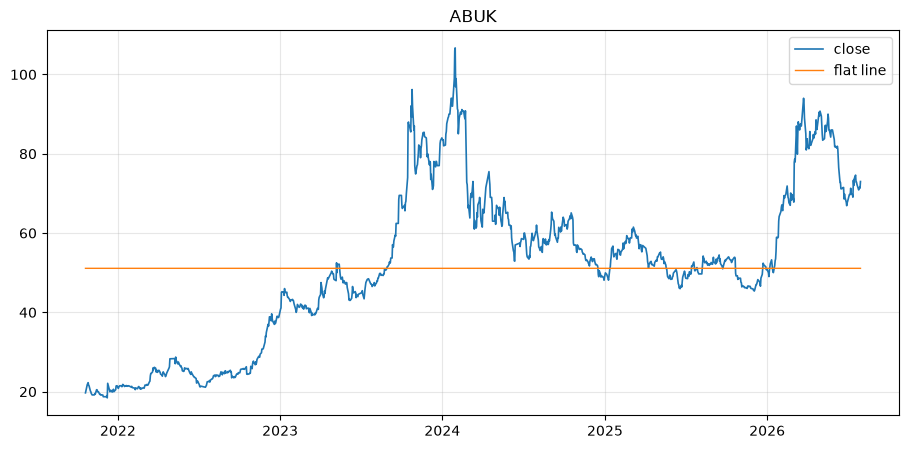

plot_price works ✓ — this is your chart tool for the whole week


In [2]:
def plot_price(dates, close, overlays=None, title='Price'):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(dates, close, label='close', linewidth=1.2)
    for name, series in (overlays or {}).items():
        ax.plot(dates, series, label=name, linewidth=1.0)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax

ax = plot_price(feed.dates, feed.close[:, 0],
                overlays={'flat line': np.full(feed.n_days, feed.close[:,0].mean())},
                title=feed.symbols[0])
assert len(ax.lines) == 2, 'expected close + 1 overlay'
plt.show()
print('plot_price works ✓ — this is your chart tool for the whole week')

In [4]:
close = feed.close[:, 0]
close

array([19.70000076, 21.77000046, 21.98999977, ..., 71.51999664,
       71.31999969, 73.        ], shape=(1159,))

In [5]:
fast_window = 20
slow_window = 50

fast_sma = np.convolve(
    close,
    np.ones(fast_window) / fast_window,
    mode='valid'
)

slow_sma = np.convolve(
    close,
    np.ones(slow_window) / slow_window,
    mode='valid'
)

print("Close:", len(close))
print("Fast SMA:", len(fast_sma))
print("Slow SMA:", len(slow_sma))

Close: 1159
Fast SMA: 1140
Slow SMA: 1110


In [6]:
fast_sma_aligned = np.full(len(close), np.nan)
slow_sma_aligned = np.full(len(close), np.nan)

fast_sma_aligned[fast_window - 1:] = fast_sma
slow_sma_aligned[slow_window - 1:] = slow_sma

In [8]:
print(len(close))
print(len(fast_sma_aligned))
print(len(slow_sma_aligned))

1159
1159
1159


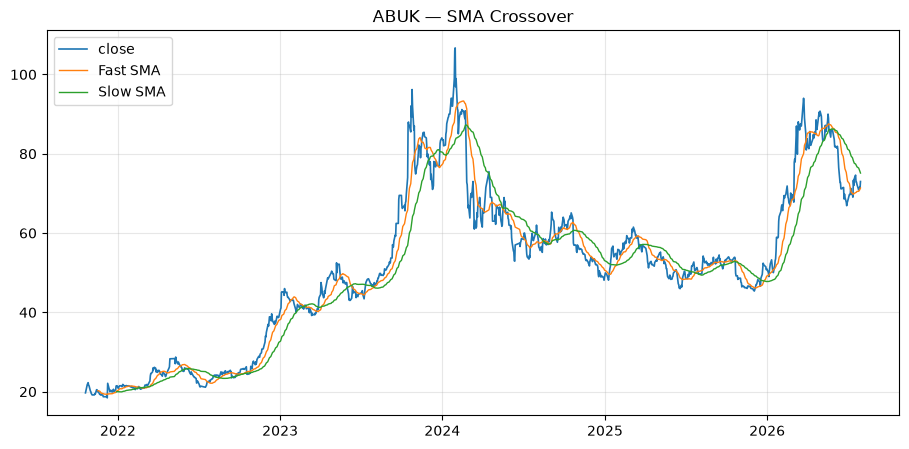

In [9]:
ax = plot_price(
    feed.dates,
    close,
    overlays={
        'Fast SMA': fast_sma_aligned,
        'Slow SMA': slow_sma_aligned
    },
    title=f'{feed.symbols[0]} — SMA Crossover'
)

plt.show()

In [10]:
buy_signal = (
    (fast_sma_aligned > slow_sma_aligned) &
    (np.roll(fast_sma_aligned, 1) <= np.roll(slow_sma_aligned, 1))
)

sell_signal = (
    (fast_sma_aligned < slow_sma_aligned) &
    (np.roll(fast_sma_aligned, 1) >= np.roll(slow_sma_aligned, 1))
)

buy_signal[0] = False
sell_signal[0] = False

print("Buy signals :", buy_signal.sum())
print("Sell signals:", sell_signal.sum())

Buy signals : 11
Sell signals: 12


## 3. What you can do this week

Now that you can see the data, here's the arc:
- **Notebook 2** — build the indicators (moving average, RSI) that turn prices into
  signals.
- **Notebook 3** — turn signals into a strategy, and write the one function at the
  heart of the whole engine.
- **Notebook 4** — backtest your strategy and **report** the result honestly against
  the benchmark.
- **Notebook 5** — put it all on a dashboard.

**Graduate** `plot_price` into `src/tradinglab/charting.py` (replace the stub), then:
`uv run pytest week1/tests/`. Tomorrow you build the indicators that go on this
chart.

In [11]:
weights = np.zeros(len(close))

position = 0.0

for i in range(len(close)):
    if buy_signal[i]:
        position = 1.0
    elif sell_signal[i]:
        position = 0.0

    weights[i] = position

print("Days invested:", int((weights == 1).sum()))
print("Days out:", int((weights == 0).sum()))

Days invested: 628
Days out: 531


In [13]:
strategy_returns = weights * feed.returns[:, 0]

print("Strategy returns shape:", strategy_returns.shape)
print("Last 5 strategy returns:", strategy_returns[-5:].round(4))

Strategy returns shape: (1159,)
Last 5 strategy returns: [-0.  0.  0. -0.  0.]


In [ ]:
strategy_equity = np.cumprod(1 + strategy_returns)
buy_hold_equity = np.cumprod(1 + feed.returns[:, 0])

print("Final strategy value:", round(strategy_equity[-1], 4))
print("Final buy & hold value:", round(buy_hold_equity[-1], 4))

Final strategy value: 2.7099
Final buy & hold value: 3.7056


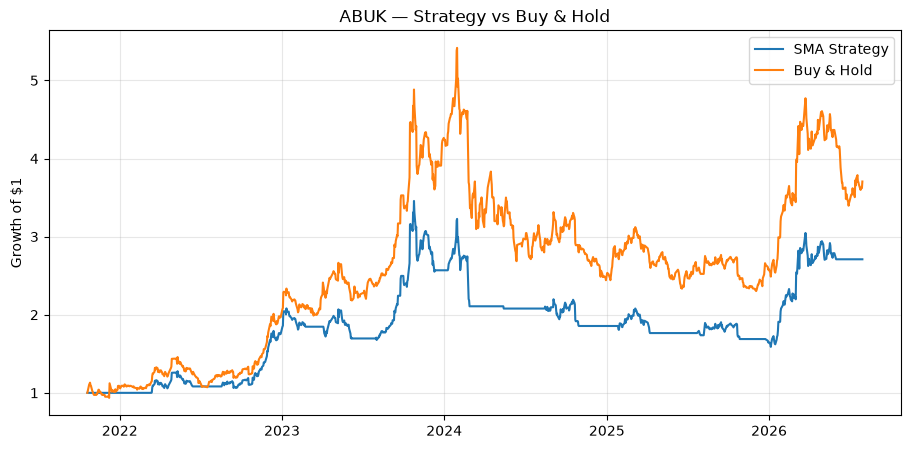

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    feed.dates,
    strategy_equity,
    label="SMA Strategy"
)

ax.plot(
    feed.dates,
    buy_hold_equity,
    label="Buy & Hold"
)

ax.set_title(f"{feed.symbols[0]} — Strategy vs Buy & Hold")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

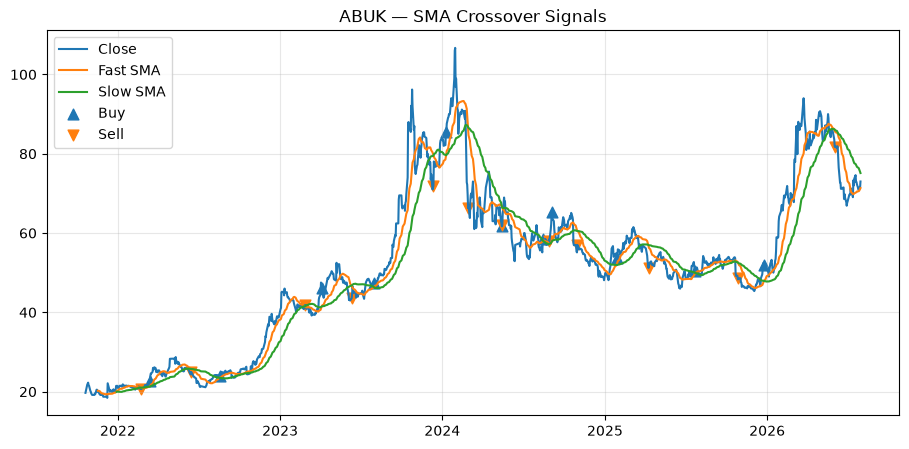

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(feed.dates, close, label="Close")
ax.plot(feed.dates, fast_sma_aligned, label="Fast SMA")
ax.plot(feed.dates, slow_sma_aligned, label="Slow SMA")

ax.scatter(
    feed.dates[buy_signal],
    close[buy_signal],
    marker="^",
    s=60,
    label="Buy"
)

ax.scatter(
    feed.dates[sell_signal],
    close[sell_signal],
    marker="v",
    s=60,
    label="Sell"
)

ax.set_title(f"{feed.symbols[0]} — SMA Crossover Signals")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [17]:
print("Number of stocks:", len(feed.symbols))
print("Stocks:", feed.symbols)
print("Price data shape:", feed.close.shape)

Number of stocks: 34
Stocks: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
Price data shape: (1159, 34)


In [41]:
from tradinglab.data_feed import DataFeed
from tradinglab.simulator import PortfolioSimulator

task_feed = DataFeed.from_dir(
    "data/egx",
    symbols=["COMI", "HRHO", "TMGH", "SWDY", "FWRY"]
)

simulator = PortfolioSimulator(
    task_feed,
    benchmark="egx30"
)

print("Stocks:", task_feed.symbols)
print("Shape:", task_feed.close.shape)

Stocks: ['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY']
Shape: (1693, 5)


In [42]:
from tradinglab.backtester import run_backtest
from tradinglab.strategies.sma import sma_crossover_weights

result = run_backtest(
    simulator,
    sma_crossover_weights,
    lookback=30
)

print(result.keys())

dict_keys(['portfolio', 'benchmark', 'portfolio_returns', 'benchmark_returns', 'dates', 'weights'])


In [43]:
portfolio_egp = result["portfolio"] * 1000
benchmark_egp = result["benchmark"] * 1000

print("Strategy final value:", round(portfolio_egp[-1], 2), "EGP")
print("EGX 30 final value:", round(benchmark_egp[-1], 2), "EGP")

print("Strategy final profit:",
      round(portfolio_egp[-1] - 1000, 2), "EGP")

print("EGX 30 final profit:",
      round(benchmark_egp[-1] - 1000, 2), "EGP")

Strategy final value: 5179.65 EGP
EGX 30 final value: 3967.15 EGP
Strategy final profit: 4179.65 EGP
EGX 30 final profit: 2967.15 EGP


In [44]:
running_max = np.maximum.accumulate(portfolio_egp)

drawdown = (portfolio_egp - running_max) / running_max

max_drawdown = drawdown.min()

print("Strategy Max Drawdown:",
      round(max_drawdown * 100, 2), "%")

Strategy Max Drawdown: -39.74 %


In [ ]:
strategy_profit = portfolio_egp[-1] - 1000
egx30_profit = benchmark_egp[-1] - 1000

print("\n===== TASK 04 REPORT =====")
print("Initial capital: 1000 EGP")
print("Strategy final value:", round(portfolio_egp[-1], 2), "EGP")
print("Strategy final profit:", round(strategy_profit, 2), "EGP")
print("Strategy Max Drawdown:", round(max_drawdown * 100, 2), "%")
print("EGX 30 final value:", round(benchmark_egp[-1], 2), "EGP")
print("EGX 30 final profit:", round(egx30_profit, 2), "EGP")


===== TASK 04 REPORT =====
Initial capital: 1000 EGP
Strategy final value: 5179.65 EGP
Strategy final profit: 4179.65 EGP
Strategy Max Drawdown: -39.74 %
EGX 30 final value: 3967.15 EGP
EGX 30 final profit: 2967.15 EGP
